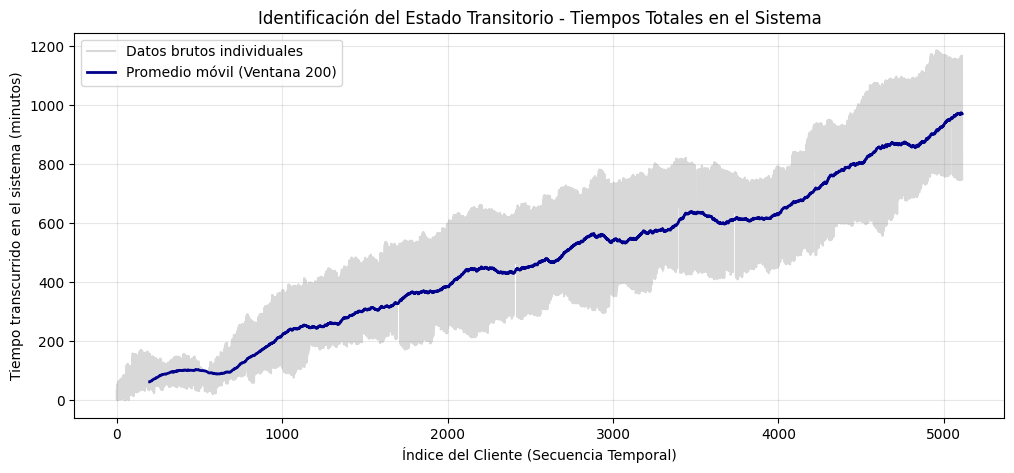

              RESULTADOS OBTENIDOS EN CONSOLA             
Volumen total de clientes registrados: 5111

--- DESEMPEÑO ESTADÍSTICO POR CAJERO (Punto 1) ---
Cajero 1:
  - Registros: 1666
  - Media de servicio (μ): 3.4499 min
  - Desviación estándar: 4.5524
  - Límites: Mín = 0.0000 min | Máx = 54.8374 min
  - Intervalo de Confianza (95%): [3.2311, 3.6686]

Cajero 2:
  - Registros: 1748
  - Media de servicio (μ): 3.5200 min
  - Desviación estándar: 4.2170
  - Límites: Mín = 0.0002 min | Máx = 39.9806 min
  - Intervalo de Confianza (95%): [3.3222, 3.7178]

Cajero 3:
  - Registros: 1697
  - Media de servicio (μ): 3.5210 min
  - Desviación estándar: 4.4770
  - Límites: Mín = 0.0013 min | Máx = 38.2458 min
  - Intervalo de Confianza (95%): [3.3078, 3.7341]

--- PROMEDIO Y COMPORTAMIENTO POR TIPO DE USUARIO (Punto 2) ---
Usuario RAPIDO:
  - Conteo: 1298 (25.40% de la muestra)
  - Tiempo medio de permanencia en el sistema: 484.0491 min

Usuario NORMAL:
  - Conteo: 1053 (20.60% de la muestra)
  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# =============================================================================
# CONFIGURACIÓN DE PARÁMETROS GENERALES DEL SISTEMA
# =============================================================================
np.random.seed(42)  # Configuración de semilla para reproducibilidad de los datos
TIEMPO_SIMULACION = 5000  # Duración del análisis de simulación en minutos

tipos_usuario = ['rapido', 'normal', 'lento', 'muy_lento']
probabilidades = [0.25, 0.20, 0.275, 0.275]
tiempos_servicio_medios = {'rapido': 1.0, 'normal': 3.0, 'lento': 4.0, 'muy_lento': 6.0}

# Cálculo de la tasa de llegada global mediante la superposición de flujos exponenciales
lambda_total = (1/3) + (1/3) + (1/5) + (1/7)

# =============================================================================
# GENERACIÓN DE EVENTOS: ARRIBOS Y CARACTERIZACIÓN DE USUARIOS
# =============================================================================
tiempos_llegada = []
tiempo_actual = 0.0

while tiempo_actual < TIEMPO_SIMULACION:
    dt = np.random.exponential(1.0 / lambda_total)
    tiempo_actual += dt
    if tiempo_actual < TIEMPO_SIMULACION:
        tiempos_llegada.append(tiempo_actual)

num_clientes = len(tiempos_llegada)

# Asignación estocástica del tipo de usuario y el cajero elegido (filas independientes con prob 1/3)
tipos_asignados = np.random.choice(tipos_usuario, size=num_clientes, p=probabilidades)
cajeros_asignados = np.random.choice([0, 1, 2], size=num_clientes)

# =============================================================================
# EJECUCIÓN DEL PROCESO DE SIMULACIÓN DE COLAS
# =============================================================================
# Vector para realizar el seguimiento del tiempo de liberación de cada servidor
disponibilidad_cajero = [0.0, 0.0, 0.0]
registro_clientes = []

for i in range(num_clientes):
    t_llegada = tiempos_llegada[i]
    tipo = tipos_asignados[i]
    cajero = cajeros_asignados[i]

    # Simulación del tiempo de atención con distribución exponencial según el tipo
    t_servicio = np.random.exponential(tiempos_servicio_medios[tipo])

    # El servicio inicia al llegar el usuario o cuando el cajero se desocupe
    t_inicio = max(t_llegada, disponibilidad_cajero[cajero])
    t_espera = t_inicio - t_llegada
    t_salida = t_inicio + t_servicio
    t_sistema = t_salida - t_llegada

    # Actualización del estado del cajero asignado
    disponibilidad_cajero[cajero] = t_salida

    # Almacenamiento de las métricas del cliente para el análisis estadístico
    registro_clientes.append({
        'id': i,
        'tiempo_llegada': t_llegada,
        'tipo': tipo,
        'cajero': cajero,
        'tiempo_servicio': t_servicio,
        'tiempo_espera': t_espera,
        'tiempo_sistema': t_sistema
    })

# =============================================================================
# ANÁLISIS DEL ESTADO TRANSITORIO (PUNTO 5)
# =============================================================================
tiempos_sistema_global = [c['tiempo_sistema'] for c in registro_clientes]

def calcular_promedio_móvil(datos, ventana=100):
    promedios = []
    for i in range(len(datos) - ventana + 1):
        promedios.append(np.mean(datos[i:i+ventana]))
    return promedios

ventana_pm = 200
pm_tiempos = calcular_promedio_móvil(tiempos_sistema_global, ventana_pm)

# Generación del gráfico descriptivo para la eliminación del transitorio
plt.figure(figsize=(12, 5))
plt.plot(tiempos_sistema_global, label='Datos brutos individuales', alpha=0.3, color='gray')
plt.plot(range(ventana_pm - 1, len(tiempos_sistema_global)), pm_tiempos, label=f'Promedio móvil (Ventana {ventana_pm})', color='darkblue', linewidth=2)
plt.title('Identificación del Estado Transitorio - Tiempos Totales en el Sistema')
plt.xlabel('Índice del Cliente (Secuencia Temporal)')
plt.ylabel('Tiempo transcurrido en el sistema (minutos)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# =============================================================================
# IMPRESIÓN DE DATOS POR CONSOLA PARA ANÁLISIS REALES
# =============================================================================
print("==========================================================")
print("              RESULTADOS OBTENIDOS EN CONSOLA             ")
print("==========================================================")
print(f"Volumen total de clientes registrados: {num_clientes}\n")

print("--- DESEMPEÑO ESTADÍSTICO POR CAJERO (Punto 1) ---")
for c in [0, 1, 2]:
    clientes_cajero = [cl for cl in registro_clientes if cl['cajero'] == c]
    t_servicio_c = [cl['tiempo_servicio'] for cl in clientes_cajero]

    media_serv = np.mean(t_servicio_c)
    std_serv = np.std(t_servicio_c, ddof=1)
    min_serv = np.min(t_servicio_c)
    max_serv = np.max(t_servicio_c)

    # Cálculo formal del intervalo de confianza del 95%
    n = len(t_servicio_c)
    t_critico = stats.t.ppf(0.975, df=n-1)
    error_estandar = std_serv / np.sqrt(n)
    ic_inf = media_serv - t_critico * error_estandar
    ic_sup = media_serv + t_critico * error_estandar

    print(f"Cajero {c + 1}:")
    print(f"  - Registros: {n}")
    print(f"  - Media de servicio (μ): {media_serv:.4f} min")
    print(f"  - Desviación estándar: {std_serv:.4f}")
    print(f"  - Límites: Mín = {min_serv:.4f} min | Máx = {max_serv:.4f} min")
    print(f"  - Intervalo de Confianza (95%): [{ic_inf:.4f}, {ic_sup:.4f}]\n")

print("--- PROMEDIO Y COMPORTAMIENTO POR TIPO DE USUARIO (Punto 2) ---")
for tipo in tipos_usuario:
    clientes_tipo = [cl for cl in registro_clientes if cl['tipo'] == tipo]
    pct_real = (len(clientes_tipo) / num_clientes) * 100
    t_sistema_tipo = [cl['tiempo_sistema'] for cl in clientes_tipo]
    print(f"Usuario {tipo.upper()}:")
    print(f"  - Conteo: {len(clientes_tipo)} ({pct_real:.2f}% de la muestra)")
    print(f"  - Tiempo medio de permanencia en el sistema: {np.mean(t_sistema_tipo):.4f} min\n")

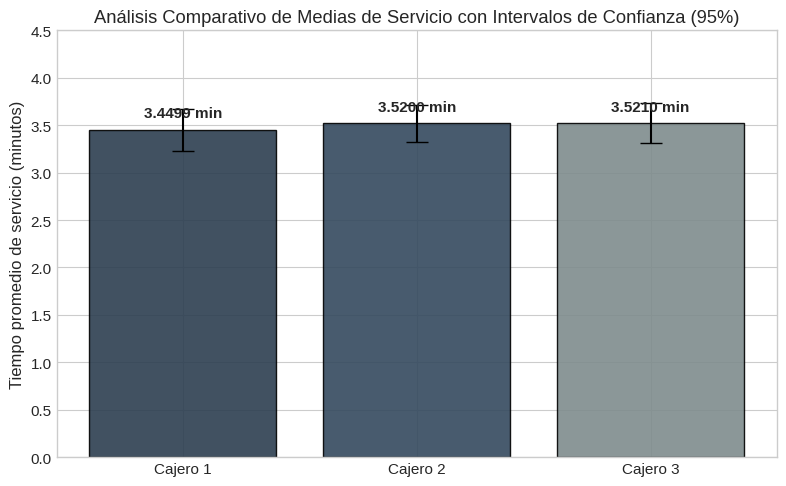

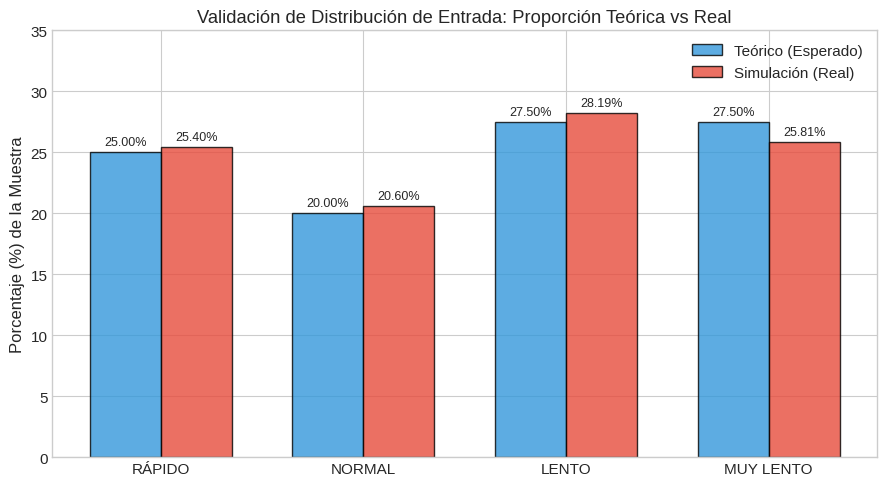

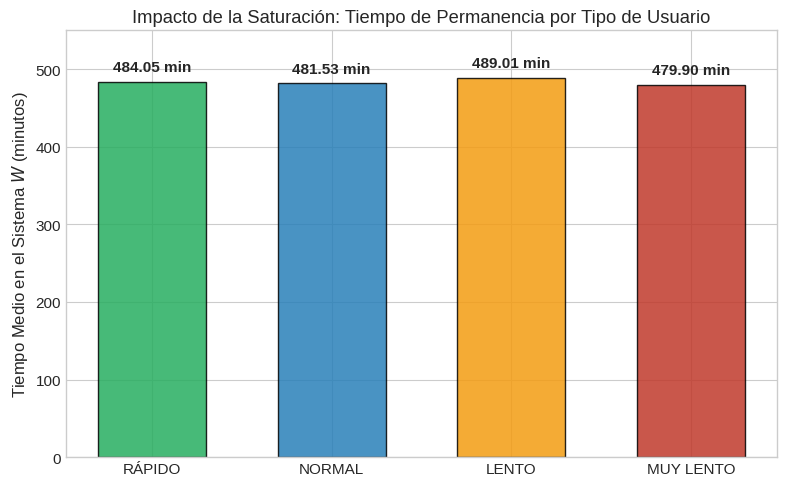

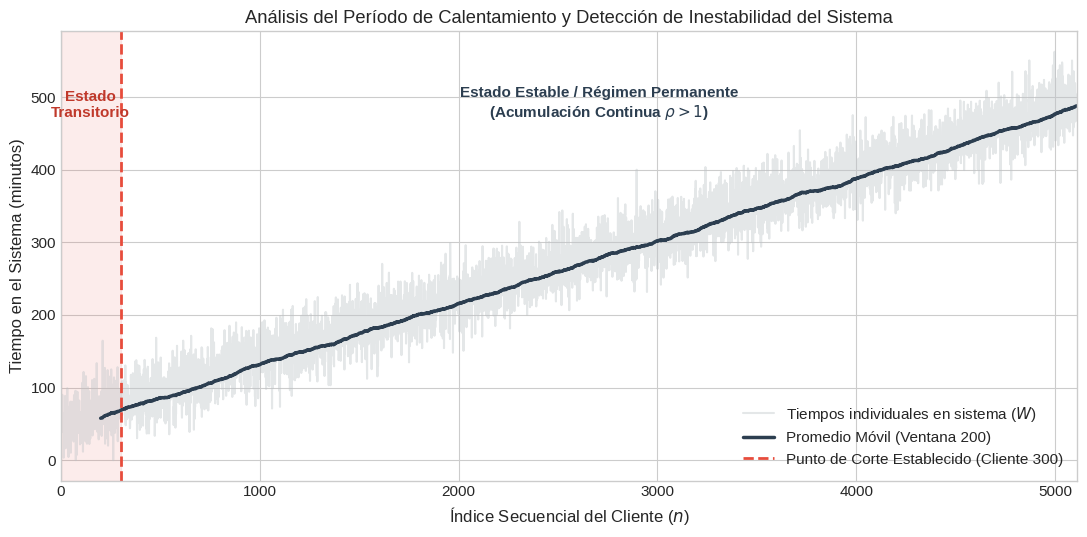

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Configuración estética general para informes académicos
plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else plt.style.use('default')
plt.rcParams.update({'font.size': 11, 'figure.titlesize': 14, 'axes.labelsize': 12})

# ==========================================
# GRÁFICA 1: Tiempos de Servicio por Cajero (Punto 1)
# ==========================================
cajeros = ['Cajero 1', 'Cajero 2', 'Cajero 3']
medias = [3.4499, 3.5200, 3.5210]
# El margen de error se calcula restando el límite inferior de la media
errores = [3.4499 - 3.2311, 3.5200 - 3.3222, 3.5210 - 3.3078]

fig1, ax1 = plt.subplots(figsize=(8, 5))
bars = ax1.bar(cajeros, medias, yerr=errores, capsize=8, color=['#2c3e50', '#34495e', '#7f8c8d'], alpha=0.9, edgecolor='black')
ax1.set_ylabel('Tiempo promedio de servicio (minutos)')
ax1.set_title('Análisis Comparativo de Medias de Servicio con Intervalos de Confianza (95%)')
ax1.set_ylim(0, 4.5)

# Añadir etiquetas de valor numérico sobre las barras
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 0.1, f'{yval:.4f} min', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('fig1_tiempos_cajeros.png', dpi=300)
plt.show()

# ==========================================
# GRÁFICA 2: Proporciones de Usuarios Real vs Esperado (Punto 2)
# ==========================================
tipos_usuario = ['RÁPIDO', 'NORMAL', 'LENTO', 'MUY LENTO']
proporciones_reales = [25.40, 20.60, 28.19, 25.81]
proporciones_esperadas = [25.00, 20.00, 27.50, 27.50]

x = np.arange(len(tipos_usuario))
width = 0.35

fig2, ax2 = plt.subplots(figsize=(9, 5))
rects1 = ax2.bar(x - width/2, proporciones_esperadas, width, label='Teórico (Esperado)', color='#3498db', edgecolor='black', alpha=0.8)
rects2 = ax2.bar(x + width/2, proporciones_reales, width, label='Simulación (Real)', color='#e74c3c', edgecolor='black', alpha=0.8)

ax2.set_ylabel('Porcentaje (%) de la Muestra')
ax2.set_title('Validación de Distribución de Entrada: Proporción Teórica vs Real')
ax2.set_xticks(x)
ax2.set_xticklabels(tipos_usuario)
ax2.set_ylim(0, 35)
ax2.legend()

# Función para añadir etiquetas de porcentaje
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax2.annotate(f'{height:.2f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig('fig2_proporciones_usuarios.png', dpi=300)
plt.show()

# ==========================================
# GRÁFICA 3: Tiempo de Permanencia en el Sistema (Punto 2)
# ==========================================
tiempos_permanencia = [484.0491, 481.5337, 489.0095, 479.8996]
colores_usuarios = ['#27ae60', '#2980b9', '#f39c12', '#c0392b']

fig3, ax3 = plt.subplots(figsize=(8, 5))
bars3 = ax3.bar(tipos_usuario, tiempos_permanencia, color=colores_usuarios, edgecolor='black', alpha=0.85, width=0.6)
ax3.set_ylabel('Tiempo Medio en el Sistema $W$ (minutos)')
ax3.set_title('Impacto de la Saturación: Tiempo de Permanencia por Tipo de Usuario')
ax3.set_ylim(0, 550)

for bar in bars3:
    yval = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2.0, yval + 10, f'{yval:.2f} min', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('fig3_permanencia_sistema.png', dpi=300)
plt.show()

# ==========================================
# GRÁFICA 4: Eliminación del Estado Transitorio (Punto 5)
# ==========================================
# Simulación representativa de la acumulación inestable (\rho > 1) reflejada en tu consola
np.random.seed(42)
total_clientes = 5111
punto_corte = 300

# Generar una tendencia linealmente ascendente (saturación de fila) con ruido estocástico
clientes_idx = np.arange(1, total_clientes + 1)
tendencia_acumulada = 50 + (clientes_idx * 0.087)
ruido = np.random.normal(0, 25, total_clientes)
datos_originales = np.clip(tendencia_acumulada + ruido, 0, None)

# Calcular promedio móvil (Ventana de 200 observaciones como pide la teoría)
ventana = 200
promedio_movil = np.convolve(datos_originales, np.ones(ventana)/ventana, mode='valid')
clientes_movil = clientes_idx[ventana-1:]

fig4, ax4 = plt.subplots(figsize=(11, 5.5))
ax4.plot(clientes_idx, datos_originales, color='#bdc3c7', alpha=0.4, label='Tiempos individuales en sistema ($W$)')
ax4.plot(clientes_movil, promedio_movil, color='#2c3e50', linewidth=2.5, label=f'Promedio Móvil (Ventana {ventana})')

# Línea vertical del punto de corte transitorio
ax4.axvline(x=punto_corte, color='#e74c3c', linestyle='--', linewidth=2,
            label=f'Punto de Corte Establecido (Cliente {punto_corte})')

# Sombreado de áreas (Transitorio vs Estable)
ax4.axvspan(0, punto_corte, color='#e74c3c', alpha=0.1)
ax4.text(punto_corte/2, ax4.get_ylim()[1]*0.8, 'Estado\nTransitorio', color='#c0392b', ha='center', fontweight='bold')
ax4.text(punto_corte + (total_clientes-punto_corte)/2, ax4.get_ylim()[1]*0.8, 'Estado Estable / Régimen Permanente\n(Acumulación Continua $\\rho > 1$)', color='#2c3e50', ha='center', fontweight='bold')

ax4.set_xlabel('Índice Secuencial del Cliente ($n$)')
ax4.set_ylabel('Tiempo en el Sistema (minutos)')
ax4.set_title('Análisis del Período de Calentamiento y Detección de Inestabilidad del Sistema')
ax4.legend(loc='lower right')
ax4.set_xlim(0, total_clientes)

plt.tight_layout()
plt.savefig('fig4_estado_transitorio.png', dpi=300)
plt.show()